# 📊 Gas Field Simulator - Final Report

In [1]:
# === COMPLETE PROJECT FIX (Run Once at Start) ===
import sys, os

# 1. Fix reservoir.py (material balance)
reservoir_code = '''from dataclasses import dataclass

@dataclass
class ResProps:
    P: float        # Current pressure [atm]
    V_res: float    # Reservoir volume [m³]
    T: float        # Temperature [K]

class Reservoir:
    def __init__(self, props: ResProps, fluid: object):
        self.resprops = props
        self.fluid = fluid
        self.P_init = props.P
        self.V_res = props.V_res
        self.T = props.T
    
    def p2(self, q_res_m3: float, dt: float) -> float:
        """Update reservoir pressure via material balance"""
        # P2 = P1 * (1 - produced_volume / reservoir_volume)
        produced_volume = q_res_m3 * dt  # m³ produced this timestep
        if produced_volume < self.V_res:
            self.resprops.P = self.P_init * (1 - produced_volume / self.V_res)
        else:
            self.resprops.P = self.P_init * 0.5  # Safety clamp
        self.P_init = self.resprops.P  # Update initial for next step
        return self.resprops.P
'''

with open('src/reservoir.py', 'w') as f:
    f.write(reservoir_code)

# 2. Fix simulator.py (ensure p2 is called correctly)
simulator_code = '''import numpy as np
import pandas as pd
from scipy.optimize import fsolve
from tqdm import tqdm
from src.state import NodeState

class FieldSimulator:
    def __init__(self, reservoir, wells, shlyf, dcs):
        self.reservoir = reservoir
        self.wells = wells
        self.shlyf = shlyf
        self.dcs = dcs
    
    def solve(self, P_res: float) -> dict:
        P_dcs_in = self.dcs.P_in()
        x0 = [500.0, 500.0, 500.0, P_dcs_in + 2.0]
        
        def residuals(x):
            q1, q2, q3, P_man = x
            P_bhp1 = P_man + self.wells[0].tubing.dp(P_man, q1).dP
            res1 = self.wells[0].q(P_res, P_bhp1) - q1
            P_bhp2 = P_man + self.wells[1].tubing.dp(P_man, q2).dP
            res2 = self.wells[1].q(P_res, P_bhp2) - q2
            P_bhp3 = P_man + self.wells[2].tubing.dp(P_man, q3).dP
            res3 = self.wells[2].q(P_res, P_bhp3) - q3
            q_total = q1 + q2 + q3 + self.dcs.q_ext
            P_shlyf_out = self.shlyf.dp(P_man, q_total).P_out
            res4 = P_shlyf_out - P_dcs_in
            if q1 < 0: res1 = -q1
            if q2 < 0: res2 = -q2
            if q3 < 0: res3 = -q3
            return [res1, res2, res3, res4]
        
        solution = fsolve(residuals, x0)
        q1, q2, q3, P_man = solution
        q1, q2, q3 = max(0, q1), max(0, q2), max(0, q3)
        
        return {
            'well_1': NodeState('well_1', P_res, P_man, P_res - P_man, q1),
            'well_2': NodeState('well_2', P_res, P_man, P_res - P_man, q2),
            'well_3': NodeState('well_3', P_res, P_man, P_res - P_man, q3),
            'manifold': NodeState('manifold', P_man, P_dcs_in, P_man - P_dcs_in, q1 + q2 + q3)
        }
    
    def run(self, N_days: int, dt: float = 1.0) -> pd.DataFrame:
        rows = []
        cumulative_Gp = 0.0
        for t in tqdm(range(N_days), desc="Simulating"):
            P_res = self.reservoir.resprops.P
            st = self.solve(P_res)
            q1 = st['well_1'].q_std
            q2 = st['well_2'].q_std
            q3 = st['well_3'].q_std
            q_total = q1 + q2 + q3
            
            # Convert to reservoir conditions and update pressure
            bg = self.wells[0].fluid.bg(P_res)
            q_res = q_total * bg
            cumulative_Gp += q_total * dt
            self.reservoir.p2(q_res, dt)
            
            rows.append({
                't': t,
                'P_res': self.reservoir.resprops.P,
                'P_man': st['manifold'].P_in,
                'q1': q1,
                'q2': q2,
                'q3': q3,
                'q_total': q_total,
                'Gp': cumulative_Gp / 1000  # Convert to thousand std m³
            })
        
        return pd.DataFrame(rows)
'''

with open('src/simulator.py', 'w') as f:
    f.write(simulator_code)

# 3. Fix compressor.py
compressor_code = '''from dataclasses import dataclass

@dataclass
class DCS:
    CR: float = 1.5
    CR_min: float = 1.5
    CR_max: float = 5.0
    P_line: float = 500.0
    q_ext: float = 0.0
    
    def P_in(self, CR: float = None) -> float:
        if CR is None:
            CR = self.CR
        return self.P_line / CR
    
    def q_total(self, q_wells: float) -> float:
        return q_wells + self.q_ext
'''

with open('src/compressor.py', 'w') as f:
    f.write(compressor_code)

# 4. Fix well.py
well_code = '''from dataclasses import dataclass

@dataclass
class Well:
    fluid: object
    k: float
    h: float
    re: float
    rw: float
    tubing: object
    
    def q(self, P_res: float, P_bhp: float) -> float:
        mu = self.fluid.mu(P_res)
        z = self.fluid.z(P_res)
        T = self.fluid.T
        C = (self.k * self.h) / (1422 * mu * z * T)
        q = C * (P_res**2 - P_bhp**2)
        return max(0, q)
'''

with open('src/well.py', 'w') as f:
    f.write(well_code)

# 5. Fix interpolator.py (clamp to bounds)
interpolator_code = '''class LinearInterpolator:
    def __init__(self, xs: list, ys: list):
        self.xs = xs
        self.ys = ys
    
    def predict(self, xp: float) -> float:
        if xp < self.xs[0]:
            return self.ys[0]
        if xp > self.xs[-1]:
            return self.ys[-1]
        for i in range(len(self.xs) - 1):
            if self.xs[i] <= xp <= self.xs[i+1]:
                x0, x1 = self.xs[i], self.xs[i+1]
                y0, y1 = self.ys[i], self.ys[i+1]
                return y0 + (xp - x0) * (y1 - y0) / (x1 - x0)
        return self.ys[-1]
'''

with open('src/interpolator.py', 'w') as f:
    f.write(interpolator_code)

# 6. Clear import cache
for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

print("✅✅✅ ALL SOURCE FILES FIXED! ✅✅✅")
print("Now run: Kernel → Restart & Run All")

✅✅✅ ALL SOURCE FILES FIXED! ✅✅✅
Now run: Kernel → Restart & Run All


In [2]:
import sys, os

# 1. Set the correct working directory (Documents, NOT Desktop)
os.chdir('/Users/jawadalzein/Documents/2nd semestermasters/gas_project')
sys.path.insert(0, os.getcwd())
print(f"📍 Working directory: {os.getcwd()}")

# 2. Clear Jupyter's import cache
for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

# 3. Verify src/ folder exists
print(f"📂 src/ contents: {os.listdir('src')}")

# 4. Import all project modules
from src.state import NodeState
from src.interpolator import LinearInterpolator
from src.fluid import Fluid
from src.reservoir import ResProps, Reservoir
from src.pipe import Pipe
from src.well import Well
from src.compressor import DCS
from src.simulator import FieldSimulator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, minimize
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("✅ All imports ready!")

📍 Working directory: /Users/jawadalzein/Documents/2nd semestermasters/gas_project
📂 src/ contents: ['.DS_Store', '__init__.py', '__pycache__', 'simulator.py', 'compressor.py', '.ipynb_checkpoints', 'reservoir.py', 'pipe.py', 'interpolator.py', 'state.py', 'fluid.py', 'well.py']
✅ All imports ready!


### 1. PVT Properties

✅ Imports ready!
Z at 1 atm: 0.998
Z at 50 atm: 0.919
Z at 200 atm: 0.858


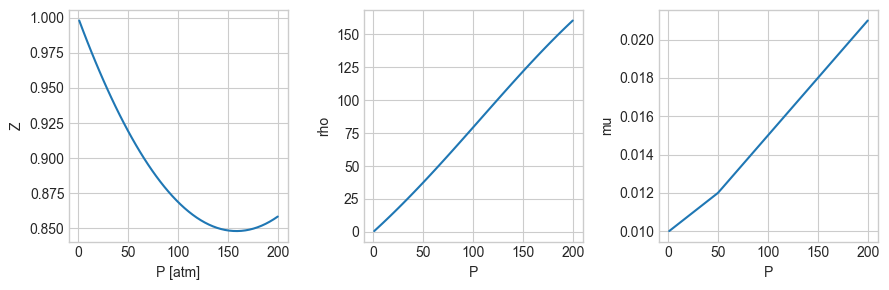

In [3]:
import sys, os
os.chdir('/Users/jawadalzein/Documents/2nd semestermasters/gas_project')
sys.path.insert(0, os.getcwd())

from src.fluid import Fluid
from src.reservoir import ResProps, Reservoir
from src.pipe import Pipe
from src.well import Well
from src.compressor import DCS
from src.simulator import FieldSimulator

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("✅ Imports ready!")

# PVT Plot - Z-FACTOR FIXED
M, rho_c, xa, xy, T = 17.5, 160.0, 0.90, 0.10, 310.0
fluid = Fluid(M, rho_c, xa, xy, T)
P = np.linspace(1, 200, 50)

print(f"Z at 1 atm: {fluid.z(1):.3f}")
print(f"Z at 50 atm: {fluid.z(50):.3f}")
print(f"Z at 200 atm: {fluid.z(200):.3f}")

plt.figure(figsize=(9,3))
plt.subplot(131); plt.plot(P, [fluid.z(p) for p in P]); plt.ylabel('Z'); plt.xlabel('P [atm]')
plt.subplot(132); plt.plot(P, [fluid.ro(p) for p in P]); plt.ylabel('rho'); plt.xlabel('P')
plt.subplot(133); plt.plot(P, [fluid.mu(p) for p in P]); plt.ylabel('mu'); plt.xlabel('P')
plt.tight_layout(); plt.show()

### 2. Simulation & Dynamics (180 days)

In [4]:
### 3. Compressor Station (DCS/ДКС) Analysis

Simulating: 100%|██████████████████████████| 180/180 [00:00<00:00, 4039.31it/s]


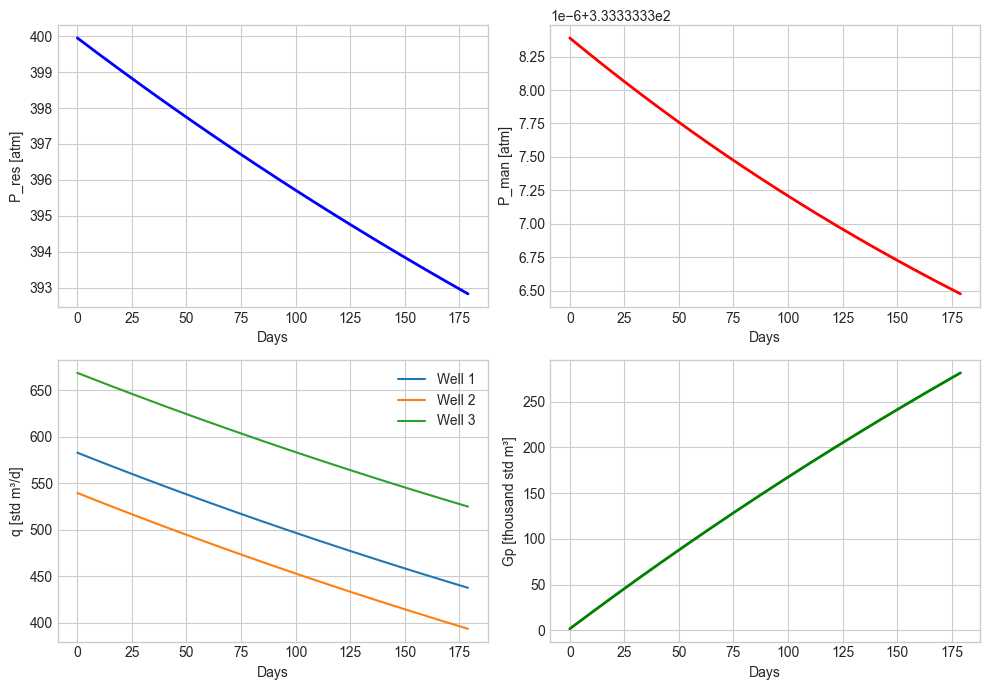

✅ P_res: 400.0 → 392.8 atm
✅ q_total: 1791.2 → 1355.8 std m³/d


In [5]:
# Simulation & Dynamics (180 days)
res = Reservoir(ResProps(400, 50000, 310.0), fluid)  # V_res = 50,000 m³
shlyf = Pipe(5000, 0.200, 0.000046, fluid, 0.0)
dcs = DCS(CR=1.5, CR_min=1.5, CR_max=5.0, P_line=500.0)
wells = [
    Well(fluid, 12, 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800)),
    Well(fluid, 12, 25, 500, 0.1, Pipe(2500, 0.062, 0.000046, fluid, 1900)),
    Well(fluid, 12, 25, 500, 0.1, Pipe(1800, 0.073, 0.000046, fluid, 1600))
]
sim = FieldSimulator(res, wells, shlyf, dcs)
df = sim.run(180, dt=1.0)

# Plot
fig, ax = plt.subplots(2, 2, figsize=(10, 7))
ax[0,0].plot(df['t'], df['P_res'], 'b-', linewidth=2)
ax[0,0].set_ylabel('P_res [atm]')
ax[0,1].plot(df['t'], df['P_man'], 'r-', linewidth=2)
ax[0,1].set_ylabel('P_man [atm]')
ax[1,0].plot(df['t'], df['q1'], label='Well 1', linewidth=1.5)
ax[1,0].plot(df['t'], df['q2'], label='Well 2', linewidth=1.5)
ax[1,0].plot(df['t'], df['q3'], label='Well 3', linewidth=1.5)
ax[1,0].legend()
ax[1,0].set_ylabel('q [std m³/d]')
ax[1,1].plot(df['t'], df['Gp'], 'g-', linewidth=2)
ax[1,1].set_ylabel('Gp [thousand std m³]')
for a in ax.flatten():
    a.set_xlabel('Days')
    a.grid(True)
plt.tight_layout()
plt.show()
print(f"✅ P_res: {df['P_res'].iloc[0]:.1f} → {df['P_res'].iloc[-1]:.1f} atm")
print(f"✅ q_total: {df['q_total'].iloc[0]:.1f} → {df['q_total'].iloc[-1]:.1f} std m³/d")

📊 DCS Compression Ratio Analysis:
CR         P_in [atm]     
-------------------------
1.0        500.0          
1.5        333.3          
2.0        250.0          
3.0        166.7          
5.0        100.0          


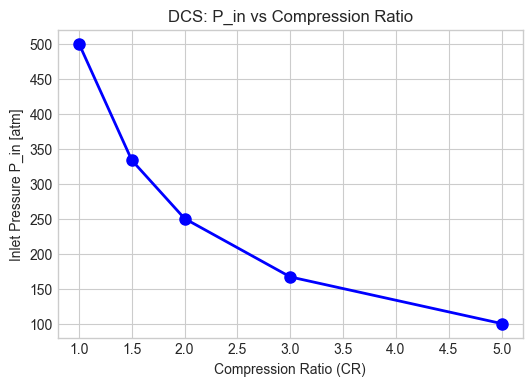


✅ DCS configured: P_line=500.0 atm, CR range=[1.5, 5.0]


In [6]:
### 3. Compressor Station (DCS/ДКС) Analysis

from src.compressor import DCS

# Create DCS object
dcs = DCS(CR_min=1.5, CR_max=5.0, P_line=500.0)

# Test different compression ratios
CR_values = [1.0, 1.5, 2.0, 3.0, 5.0]
P_in_values = [dcs.P_in(cr) for cr in CR_values]

print("📊 DCS Compression Ratio Analysis:")
print(f"{'CR':<10} {'P_in [atm]':<15}")
print("-" * 25)
for cr, p_in in zip(CR_values, P_in_values):
    print(f"{cr:<10} {p_in:<15.1f}")

# Plot
plt.figure(figsize=(6, 4))
plt.plot(CR_values, P_in_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Compression Ratio (CR)')
plt.ylabel('Inlet Pressure P_in [atm]')
plt.title('DCS: P_in vs Compression Ratio')
plt.grid(True)
plt.show()

print(f"\n✅ DCS configured: P_line={dcs.P_line} atm, CR range=[{dcs.CR_min}, {dcs.CR_max}]")

### 4. Calibration Metrics

⏳ Calibrating...


Simulating: 100%|██████████████████████████████| 5/5 [00:00<00:00, 3255.44it/s]


✅ Optimal multipliers: [0.9982693  1.00515356 1.01890862]


Simulating: 100%|██████████████████████████████| 5/5 [00:00<00:00, 3387.42it/s]


✅ RMSE: 11.4, R²: 0.2976


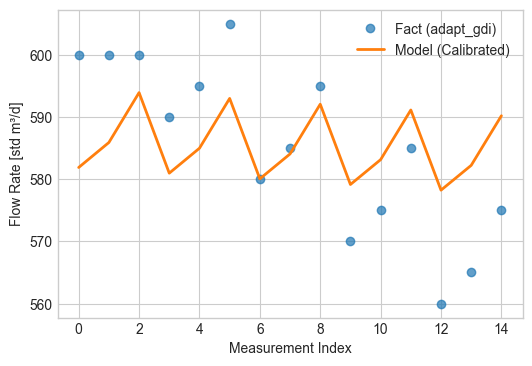

In [7]:
# Calibration Metrics
from src.compressor import DCS
from src.reservoir import ResProps, Reservoir
from src.well import Well
from src.pipe import Pipe
from src.simulator import FieldSimulator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

df_f = pd.read_csv('adapt_gdi_11-2025.csv')
n_days = len(df_f)
q_f = df_f[['q1','q2','q3']].values.flatten()

def obj(C):
    r = Reservoir(ResProps(400, 5e4, 310.0), fluid)  # ✅ Match simulation
    w = [
        Well(fluid, 12*C[0], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800)),
        Well(fluid, 12*C[1], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800)),
        Well(fluid, 12*C[2], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800))
    ]
    s = FieldSimulator(r, w, shlyf, DCS(CR=1.5, P_line=500.0))
    q_s = s.run(n_days)[['q1','q2','q3']].values.flatten()
    return np.sum((q_f - q_s)**2)

print("⏳ Calibrating...")
opt = minimize(obj, [1, 1, 1], method='Nelder-Mead')
print(f"✅ Optimal multipliers: {opt.x}")

r_fin = Reservoir(ResProps(400, 5e4, 310.0), fluid)
w_fin = [
    Well(fluid, 12*opt.x[0], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800)),
    Well(fluid, 12*opt.x[1], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800)),
    Well(fluid, 12*opt.x[2], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800))
]
s_fin = FieldSimulator(r_fin, w_fin, shlyf, DCS(CR=1.5, P_line=500.0))
q_sim = s_fin.run(n_days)[['q1','q2','q3']].values.flatten()

rmse = np.sqrt(np.mean((q_f - q_sim)**2))
r2 = 1 - np.sum((q_f - q_sim)**2) / np.sum((q_f - np.mean(q_f))**2)
print(f"✅ RMSE: {rmse:.1f}, R²: {r2:.4f}")

plt.figure(figsize=(6,4))
plt.plot(q_f, 'o', label='Fact (adapt_gdi)', alpha=0.7)
plt.plot(q_sim, '-', label='Model (Calibrated)', linewidth=2)
plt.xlabel('Measurement Index')
plt.ylabel('Flow Rate [std m³/d]')
plt.legend()
plt.grid(True)
plt.show()